# NB03c — Frozen V-JEPA Embeddings on the Curated Subset

This notebook is the **representation-side companion** to `NB03b`. It does not attempt
OCR or semantic extraction. Instead, it asks a narrower question:

> can a frozen JEPA-family encoder produce useful visual-structure embeddings from the
> same curated menu-image subset on local hardware?

The purpose is to gather direct evidence about:

- local feasibility of frozen JEPA inference
- whether visually similar menu pages cluster together
- whether unusual or weak pages appear as outliers
- how far a representation layer can support later governance and curation analysis

Main outputs:

- `data/processed/menu_image_subset_v1_vjepa_embeddings.npy`
- `data/processed/menu_image_subset_v1_vjepa_embedding_index.csv`
- `data/processed/menu_image_subset_v1_vjepa_cosine_similarity.csv`
- `outputs/figures/nb03c/fig25_vjepa_pca_by_source.png`
- `outputs/figures/nb03c/fig26_vjepa_pca_by_qwen_signal.png`
- `outputs/figures/nb03c/fig27_vjepa_outlier_scores.png`

This is a **frozen-encoder evidence notebook**, not a training notebook.

## 1. Environment setup

This notebook works on the fixed Phase 3 subset only and keeps the hardware policy simple:

- one model at a time
- no fine-tuning
- frozen encoder only
- small-N evidence over ambitious scale

In [1]:
from __future__ import annotations

import gc
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, ImageOps
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import torch
import yaml

ROOT = Path().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "configs").exists(), f"Cannot find project root from {Path().resolve()}"

PROCESSED_DIR = ROOT / "data" / "processed"
SUBSET_PATH = PROCESSED_DIR / "menu_image_subset_v1.csv"
QWEN_PATH = PROCESSED_DIR / "menu_image_subset_v1_qwen_understanding.csv"
MODEL_REGISTRY = ROOT / "configs" / "model_registry.yaml"
EMBED_NPY = PROCESSED_DIR / "menu_image_subset_v1_vjepa_embeddings.npy"
EMBED_INDEX_CSV = PROCESSED_DIR / "menu_image_subset_v1_vjepa_embedding_index.csv"
SIMILARITY_CSV = PROCESSED_DIR / "menu_image_subset_v1_vjepa_cosine_similarity.csv"
FIG_DIR = ROOT / "outputs" / "figures" / "nb03c"
FIG_DIR.mkdir(parents=True, exist_ok=True)

assert SUBSET_PATH.exists(), f"Subset file not found: {SUBSET_PATH}"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 150, "savefig.bbox": "tight"})

print(f"Project root : {ROOT}")
print(f"Subset path  : {SUBSET_PATH}")
print(f"Qwen path    : {QWEN_PATH}")
print(f"Embeddings   : {EMBED_NPY}")
print(f"Index CSV    : {EMBED_INDEX_CSV}")
print(f"Similarity   : {SIMILARITY_CSV}")
print(f"Figure dir   : {FIG_DIR}")

Project root : /home/endy/menuforge
Subset path  : /home/endy/menuforge/data/processed/menu_image_subset_v1.csv
Qwen path    : /home/endy/menuforge/data/processed/menu_image_subset_v1_qwen_understanding.csv
Embeddings   : /home/endy/menuforge/data/processed/menu_image_subset_v1_vjepa_embeddings.npy
Index CSV    : /home/endy/menuforge/data/processed/menu_image_subset_v1_vjepa_embedding_index.csv
Similarity   : /home/endy/menuforge/data/processed/menu_image_subset_v1_vjepa_cosine_similarity.csv
Figure dir   : /home/endy/menuforge/outputs/figures/nb03c


## 2. Load the curated subset and optional Qwen evidence

If the `NB03b` output exists, it is used only as a **supporting semantic layer** for later
comparison. JEPA itself remains purely visual in this notebook.

In [2]:
subset = pd.read_csv(SUBSET_PATH).copy()

if QWEN_PATH.exists():
    qwen = pd.read_csv(QWEN_PATH).copy()
    qwen_keep = [
        "path",
        "run_status",
        "page_type",
        "extraction_utility",
        "quality_confidence_note",
    ]
    qwen_keep = [col for col in qwen_keep if col in qwen.columns]
    subset = subset.merge(
        qwen[qwen_keep].rename(columns={
            "run_status": "qwen_run_status",
            "page_type": "qwen_page_type",
            "extraction_utility": "qwen_extraction_utility",
            "quality_confidence_note": "qwen_quality_confidence_note",
        }),
        on="path",
        how="left",
    )
    qwen_available = True
else:
    qwen_available = False

print(f"Subset size      : {len(subset)}")
print(f"Qwen evidence    : {qwen_available}")
print()
print("By source:")
print(subset["source"].value_counts().to_string())
print()

cols = [
    "subset_role",
    "source",
    "filename",
    "final_score",
    "qwen_run_status",
    "qwen_extraction_utility",
]
cols = [col for col in cols if col in subset.columns]
display(subset[cols])

Subset size      : 16
Qwen evidence    : True

By source:
source
yelp_american    7
wikimedia        6
nypl             3



,subset_role,source,filename,final_score,qwen_run_status,qwen_extraction_utility
0,core_auto,nypl,32956.jpg,5.23,ok,low
1,core_auto,nypl,39099.jpg,4.74,error,NaN
2,core_auto,nypl,35095.jpg,4.47,error,NaN
3,core_auto,wikimedia,Menu of 17 GRAMS 2025-05-28.jpg,9.20,ok,high
4,core_auto,wikimedia,Menu of HOKO (English) 2024-12-21.jpg,8.24,error,NaN
5,core_auto,wikimedia,"Menu of Cadence Clubhouse, Newhaven Fort 2025-...",7.83,error,NaN
6,core_auto,wikimedia,Menu of Albina (1) 2024-11-27.jpg,7.39,ok,high
7,core_auto,wikimedia,"Menu (1) of Cafe Rust, Preston Road, Brighton ...",7.20,error,NaN
8,core_auto,wikimedia,"Menu (2) of Cafe Rust, Preston Road, Brighton ...",7.02,error,NaN
9,core_auto,yelp_american,zRqxhL87dwVrpcZh5qc6_w.jpg,5.00,error,NaN


## 3. V-JEPA readiness check

`NB03a` already established that the local checkpoint can load on CUDA in your notebook
runtime. This cell checks that the same checkpoint path is still present here.

In [3]:
with open(MODEL_REGISTRY, "r", encoding="utf-8") as f:
    registry = yaml.safe_load(f)["models"]

cfg = registry["vjepa2_vitl"]
model_path_raw = Path(cfg["path"])
MODEL_PATH = model_path_raw if model_path_raw.is_absolute() else ROOT / model_path_raw

status_df = pd.DataFrame([
    {
        "asset": "vjepa2_vitl checkpoint",
        "path": str(MODEL_PATH),
        "exists": MODEL_PATH.exists(),
        "ready_flag": cfg.get("ready", None),
    }
])

display(status_df)
assert MODEL_PATH.exists(), f"Model directory not found: {MODEL_PATH}"


,asset,path,exists,ready_flag
0,vjepa2_vitl checkpoint,/home/endy/menuforge/models/vjepa2-vitl-fpc64-256,True,True


## 4. Still-image adaptation note

V-JEPA 2 is video-native. MenuForge's Phase 3 subset consists of still images. To keep the
experiment realistic and small, this notebook uses a transparent approximation:

- each still menu image is repeated into a short pseudo-clip
- the clip is processed by the frozen V-JEPA 2 encoder
- token embeddings are mean-pooled into one image-level vector

This is **not** a claim that V-JEPA was used in its fully intended video setting. It is a
local-feasibility probe for visual-structure representations on static menu pages.

In [4]:
FRAME_COUNT = 8
OVERWRITE_EXISTING_EMBEDDINGS = True


def build_pseudoclip(image_path: str | Path, frame_count: int = FRAME_COUNT) -> tuple[list[Image.Image], tuple[int, int]]:
    image_path = Path(image_path)
    with Image.open(image_path) as im:
        im = ImageOps.exif_transpose(im).convert("RGB")
        original_size = im.size
        base = im.copy()
    frames = [base.copy() for _ in range(frame_count)]
    return frames, original_size


def normalize_qwen_value(value, fallback: str = "missing") -> str:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return fallback
    value = str(value).strip().lower()
    if not value:
        return fallback
    return {
        "moderate": "medium",
        "restaurant menu": "menu_page",
    }.get(value, value)


def run_vjepa_on_image(model, processor, image_path: str | Path, device: str) -> tuple[np.ndarray, dict]:
    frames, original_size = build_pseudoclip(image_path, frame_count=FRAME_COUNT)
    inputs = processor(videos=[frames], return_tensors="pt")
    pixel_values = inputs["pixel_values_videos"].to(device)

    t0 = time.perf_counter()
    with torch.inference_mode():
        outputs = model(pixel_values_videos=pixel_values, skip_predictor=True)
        embedding = outputs.last_hidden_state.mean(dim=1).squeeze(0).float().cpu().numpy()
    elapsed_s = round(time.perf_counter() - t0, 2)

    meta = {
        "original_w": original_size[0],
        "original_h": original_size[1],
        "input_frames": FRAME_COUNT,
        "embedding_dim": int(embedding.shape[0]),
        "embedding_norm": float(np.linalg.norm(embedding)),
        "elapsed_s": elapsed_s,
    }
    return embedding, meta

## 5. Load the frozen V-JEPA 2 stack

The encoder is loaded once, used sequentially on the curated subset, and then released.

In [5]:
from transformers import VJEPA2Model, VJEPA2VideoProcessor

processor = VJEPA2VideoProcessor.from_pretrained(MODEL_PATH)
model = VJEPA2Model.from_pretrained(MODEL_PATH)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

print({
    "model_path": str(MODEL_PATH),
    "device": device,
    "frame_count": FRAME_COUNT,
})

{'model_path': '/home/endy/menuforge/models/vjepa2-vitl-fpc64-256', 'device': 'cuda', 'frame_count': 8}


## 6. Extract and save embeddings

This pass keeps the output format simple:

- one `.npy` matrix for vectors
- one `.csv` index for row-level metadata
- one cosine-similarity matrix for inspection and downstream analysis

In [6]:
records = []
embeddings = []

if not OVERWRITE_EXISTING_EMBEDDINGS and EMBED_INDEX_CSV.exists() and EMBED_NPY.exists():
    records = pd.read_csv(EMBED_INDEX_CSV).to_dict(orient="records")
    embeddings = list(np.load(EMBED_NPY))

existing_paths = {record["path"] for record in records if "path" in record}
pending = subset.loc[~subset["path"].isin(existing_paths)].copy()

print(f"Overwrite existing embeddings: {OVERWRITE_EXISTING_EMBEDDINGS}")
print(f"Existing records             : {len(existing_paths)}")
print(f"Pending images               : {len(pending)}")

for idx, (_, row) in enumerate(pending.iterrows(), start=1):
    print(f"[{idx}/{len(pending)}] {row['source']} | {row['filename']}")
    embedding, meta = run_vjepa_on_image(
        model=model,
        processor=processor,
        image_path=row["path"],
        device=device,
    )

    record = {
        "path": row["path"],
        "filename": row["filename"],
        "source": row["source"],
        "subset_role": row.get("subset_role"),
        "selection_mode": row.get("selection_mode"),
        "final_score": row.get("final_score"),
        "qwen_run_status": row.get("qwen_run_status"),
        "qwen_page_type": row.get("qwen_page_type"),
        "qwen_extraction_utility": row.get("qwen_extraction_utility"),
        "qwen_quality_confidence_note": row.get("qwen_quality_confidence_note"),
        **meta,
    }

    records.append(record)
    embeddings.append(embedding)

    ordered_records = []
    ordered_embeddings = []
    path_to_record = {record["path"]: record for record in records}
    path_to_embedding = {record["path"]: embedding for record, embedding in zip(records, embeddings)}

    for path in subset["path"]:
        if path in path_to_record and path in path_to_embedding:
            ordered_records.append(path_to_record[path])
            ordered_embeddings.append(path_to_embedding[path])

    pd.DataFrame(ordered_records).to_csv(EMBED_INDEX_CSV, index=False)
    np.save(EMBED_NPY, np.stack(ordered_embeddings))

print()
print(f"Saved embeddings to {EMBED_NPY}")
print(f"Saved index CSV  to {EMBED_INDEX_CSV}")

Overwrite existing embeddings: True
Existing records             : 0
Pending images               : 16
[1/16] nypl | 32956.jpg
[2/16] nypl | 39099.jpg
[3/16] nypl | 35095.jpg
[4/16] wikimedia | Menu of 17 GRAMS 2025-05-28.jpg
[5/16] wikimedia | Menu of HOKO (English) 2024-12-21.jpg
[6/16] wikimedia | Menu of Cadence Clubhouse, Newhaven Fort 2025-03-02.jpg
[7/16] wikimedia | Menu of Albina (1) 2024-11-27.jpg
[8/16] wikimedia | Menu (1) of Cafe Rust, Preston Road, Brighton 2025-03-31.jpg
[9/16] wikimedia | Menu (2) of Cafe Rust, Preston Road, Brighton 2025-03-31.jpg
[10/16] yelp_american | zRqxhL87dwVrpcZh5qc6_w.jpg
[11/16] yelp_american | uc0AkkGTWDwZzS4oz4Dsrw.jpg
[12/16] yelp_american | Cg-hcHviuNYcz2BzgtfPvw.jpg
[13/16] yelp_american | kyKLI8xuBfL_gYzJMqdzCA.jpg
[14/16] yelp_american | ORI7fozEGnD7miFv-2oZaA.jpg
[15/16] yelp_american | HboXWB0IlVBenLE7LEqOZA.jpg
[16/16] yelp_american | fimbhW72KR8QnoZGxUJEEw.jpg

Saved embeddings to /home/endy/menuforge/data/processed/menu_image_subs

## 7. Build similarity and outlier summaries

Mean cosine similarity is used here as a simple outlier proxy:

- higher mean similarity = image sits closer to the rest of the subset
- lower mean similarity = image is more visually distinct or isolated

That is a useful governance signal even when the subset is small.

In [7]:
embedding_df = pd.read_csv(EMBED_INDEX_CSV)
embedding_matrix = np.load(EMBED_NPY)

sim = cosine_similarity(embedding_matrix)
sim_df = pd.DataFrame(sim, index=embedding_df["filename"], columns=embedding_df["filename"])
sim_df.to_csv(SIMILARITY_CSV)

mean_cos = []
nearest_name = []
nearest_score = []

for i in range(len(embedding_df)):
    row = sim[i].copy()
    row[i] = -1.0
    nearest_idx = int(np.argmax(row))
    nearest_name.append(embedding_df.iloc[nearest_idx]["filename"])
    nearest_score.append(round(float(row[nearest_idx]), 4))

    others = np.delete(sim[i], i)
    mean_cos.append(round(float(np.mean(others)), 4))

embedding_df["mean_cosine_to_others"] = mean_cos
embedding_df["nearest_neighbor_filename"] = nearest_name
embedding_df["nearest_neighbor_score"] = nearest_score
embedding_df["qwen_run_status_plot"] = embedding_df["qwen_run_status"].map(normalize_qwen_value)
embedding_df["qwen_page_type_plot"] = embedding_df["qwen_page_type"].map(normalize_qwen_value)
embedding_df["qwen_extraction_utility_plot"] = embedding_df["qwen_extraction_utility"].map(normalize_qwen_value)

embedding_df.to_csv(EMBED_INDEX_CSV, index=False)

display(
    embedding_df[[
        "source",
        "subset_role",
        "filename",
        "embedding_dim",
        "embedding_norm",
        "elapsed_s",
        "mean_cosine_to_others",
        "nearest_neighbor_filename",
        "nearest_neighbor_score",
        "qwen_run_status_plot",
        "qwen_extraction_utility_plot",
    ]]
    .sort_values("mean_cosine_to_others")
    .reset_index(drop=True)
)

print(f"Saved similarity matrix to {SIMILARITY_CSV}")

,source,subset_role,filename,embedding_dim,embedding_norm,elapsed_s,mean_cosine_to_others,nearest_neighbor_filename,nearest_neighbor_score,qwen_run_status_plot,qwen_extraction_utility_plot
0,nypl,core_auto,39099.jpg,1024,60.524982,0.15,0.5327,35095.jpg,0.7221,error,missing
1,yelp_american,edge_auto,kyKLI8xuBfL_gYzJMqdzCA.jpg,1024,54.750137,0.14,0.6147,fimbhW72KR8QnoZGxUJEEw.jpg,0.8540,ok,medium
2,nypl,core_auto,35095.jpg,1024,54.718536,0.15,0.6212,39099.jpg,0.7221,error,missing
3,wikimedia,core_auto,"Menu of Cadence Clubhouse, Newhaven Fort 2025-...",1024,53.979820,0.39,0.6355,Menu of Albina (1) 2024-11-27.jpg,0.7667,error,missing
4,yelp_american,core_auto,zRqxhL87dwVrpcZh5qc6_w.jpg,1024,54.221420,0.14,0.6403,fimbhW72KR8QnoZGxUJEEw.jpg,0.7903,error,missing
5,nypl,core_auto,32956.jpg,1024,50.940853,0.84,0.6593,"Menu of Cadence Clubhouse, Newhaven Fort 2025-...",0.7193,ok,low
6,yelp_american,core_auto,uc0AkkGTWDwZzS4oz4Dsrw.jpg,1024,54.229958,0.15,0.6727,fimbhW72KR8QnoZGxUJEEw.jpg,0.8039,ok,medium
7,wikimedia,core_auto,Menu of 17 GRAMS 2025-05-28.jpg,1024,51.566372,0.16,0.6905,Menu of Albina (1) 2024-11-27.jpg,0.8960,ok,high
8,yelp_american,core_auto,Cg-hcHviuNYcz2BzgtfPvw.jpg,1024,54.596779,0.15,0.6906,fimbhW72KR8QnoZGxUJEEw.jpg,0.8772,ok,high
9,yelp_american,edge_auto,HboXWB0IlVBenLE7LEqOZA.jpg,1024,54.845406,0.15,0.6919,ORI7fozEGnD7miFv-2oZaA.jpg,0.9887,ok,medium


Saved similarity matrix to /home/endy/menuforge/data/processed/menu_image_subset_v1_vjepa_cosine_similarity.csv


## 8. Figure 25 — PCA projection by source

This figure is only a visual aid. It is not a claim of clean class separation. With 16
images, the right question is whether the embedding space shows plausible grouping and
useful contrast cases.

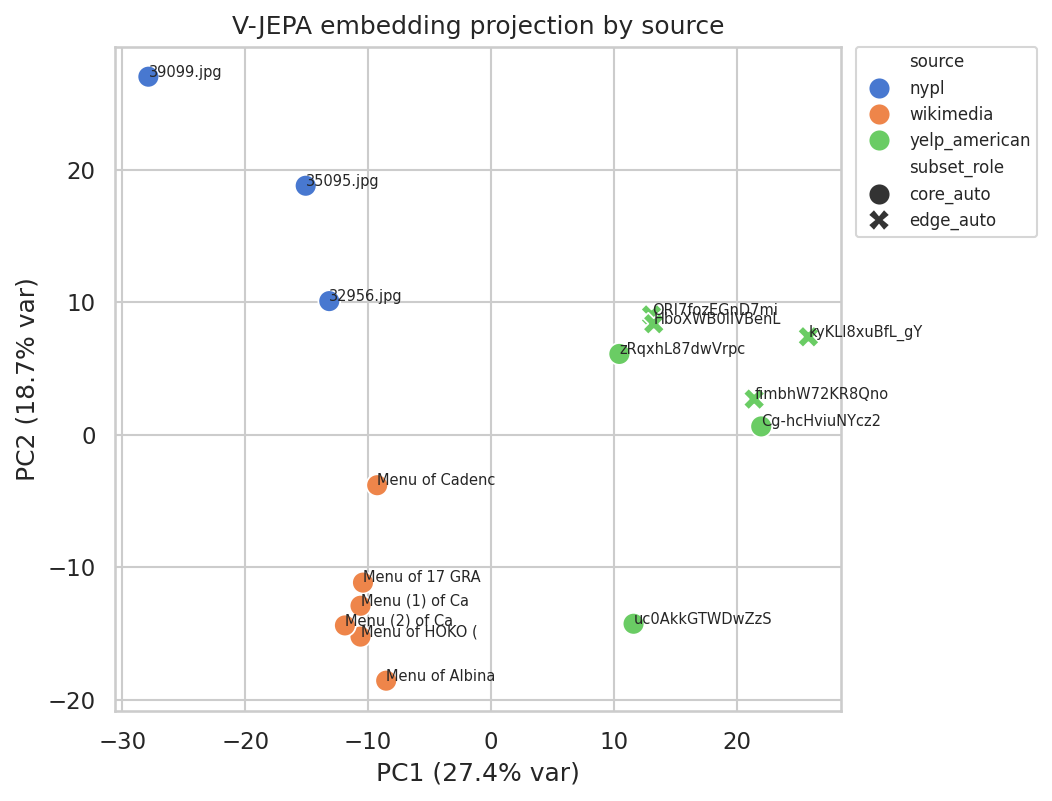

Saved figure: /home/endy/menuforge/outputs/figures/nb03c/fig25_vjepa_pca_by_source.png


In [8]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embedding_matrix)

plot_df = embedding_df.copy()
plot_df["pc1"] = coords[:, 0]
plot_df["pc2"] = coords[:, 1]

fig, ax = plt.subplots(figsize=(8.8, 5.5))
sns.scatterplot(
    data=plot_df,
    x="pc1",
    y="pc2",
    hue="source",
    style="subset_role",
    s=110,
    ax=ax,
)

for _, row in plot_df.iterrows():
    ax.text(row["pc1"] + 0.01, row["pc2"] + 0.01, row["filename"][:14], fontsize=7)

ax.set_title("V-JEPA embedding projection by source")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")

if ax.get_legend() is not None:
    try:
        sns.move_legend(
            ax,
            "upper left",
            bbox_to_anchor=(1.02, 1.0),
            borderaxespad=0.0,
            frameon=True,
            fontsize=8,
            title_fontsize=9,
        )
    except Exception:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles,
            labels,
            loc="upper left",
            bbox_to_anchor=(1.02, 1.0),
            borderaxespad=0.0,
            frameon=True,
            fontsize=8,
            title_fontsize=9,
        )

fig.tight_layout(rect=(0, 0, 0.82, 1))

fig25 = FIG_DIR / "fig25_vjepa_pca_by_source.png"
fig.savefig(fig25)
plt.show()

print(f"Saved figure: {fig25}")

## 8b. Optional exploratory companion — UMAP by source

This is an **exploratory companion only** for the small-N subset. Keep PCA as the primary
published view in the notebook and in the horizon scan. Run this cell only if you want a
non-linear comparison lens alongside the main PCA figure.

In [13]:
import sys
!{sys.executable} -m pip install umap-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 24.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.2 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [umap-learn]4 [umap-learn]


/home/endy/menuforge/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


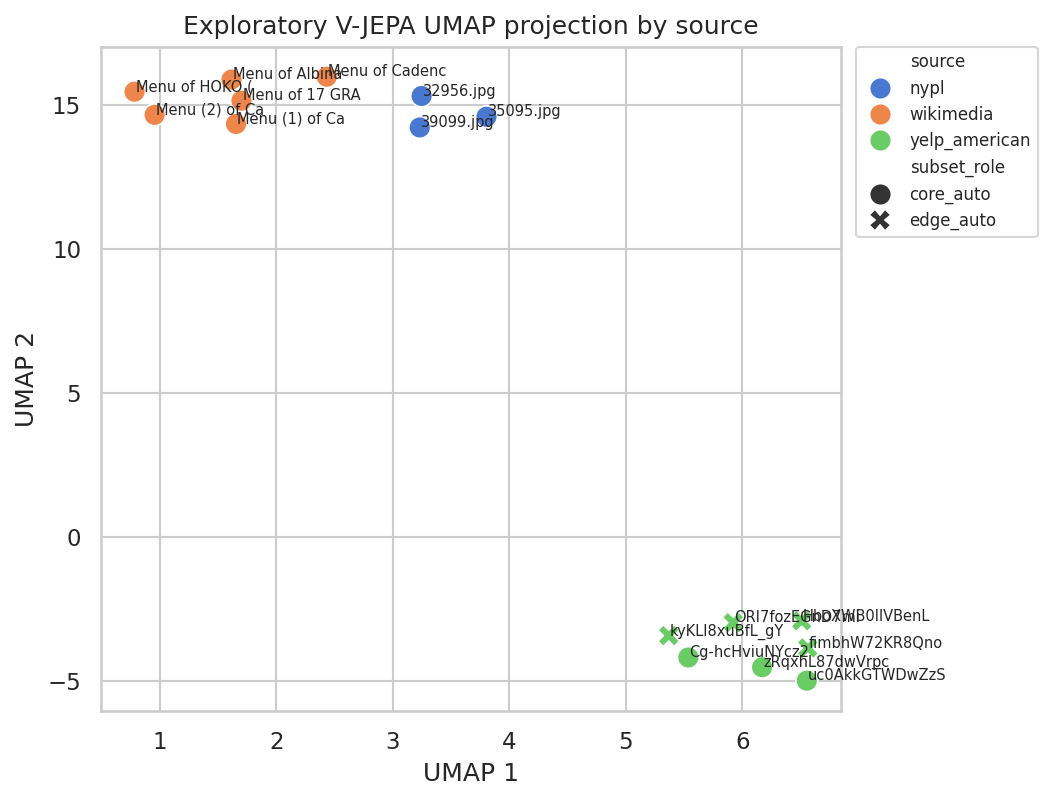

Exploratory companion only; keep PCA as the primary published view.
Saved figure: /home/endy/menuforge/outputs/figures/nb03c/fig25b_vjepa_umap_by_source.png


In [14]:
try:
    import umap
except ModuleNotFoundError:
    print("UMAP companion skipped: install `umap-learn` only if you want the extra exploratory view.")
else:
    n_neighbors = max(2, min(5, len(plot_df) - 1))
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=0.35,
        metric="cosine",
        random_state=42,
    )
    umap_coords = reducer.fit_transform(embedding_matrix)

    umap_df = plot_df.copy()
    umap_df["umap1"] = umap_coords[:, 0]
    umap_df["umap2"] = umap_coords[:, 1]

    fig, ax = plt.subplots(figsize=(8.8, 5.5))
    sns.scatterplot(
        data=umap_df,
        x="umap1",
        y="umap2",
        hue="source",
        style="subset_role",
        s=110,
        ax=ax,
    )

    for _, row in umap_df.iterrows():
        ax.text(row["umap1"] + 0.01, row["umap2"] + 0.01, row["filename"][:14], fontsize=7)

    ax.set_title("Exploratory V-JEPA UMAP projection by source")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

    if ax.get_legend() is not None:
        try:
            sns.move_legend(
                ax,
                "upper left",
                bbox_to_anchor=(1.02, 1.0),
                borderaxespad=0.0,
                frameon=True,
                fontsize=8,
                title_fontsize=9,
            )
        except Exception:
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(
                handles,
                labels,
                loc="upper left",
                bbox_to_anchor=(1.02, 1.0),
                borderaxespad=0.0,
                frameon=True,
                fontsize=8,
                title_fontsize=9,
            )

    fig.tight_layout(rect=(0, 0, 0.82, 1))

    fig25b = FIG_DIR / "fig25b_vjepa_umap_by_source.png"
    fig.savefig(fig25b)
    plt.show()

    print("Exploratory companion only; keep PCA as the primary published view.")
    print(f"Saved figure: {fig25b}")

## 9. Figure 26 — PCA projection by Qwen signal

If `NB03b` outputs exist, this figure uses them only as an external comparison layer:

- `high / medium / low` = Qwen thought the page was more or less useful
- `missing` = Qwen failed or no Qwen output exists

This does **not** make Qwen the ground truth. It only asks whether the JEPA space gives
plausible support for the same distinction.

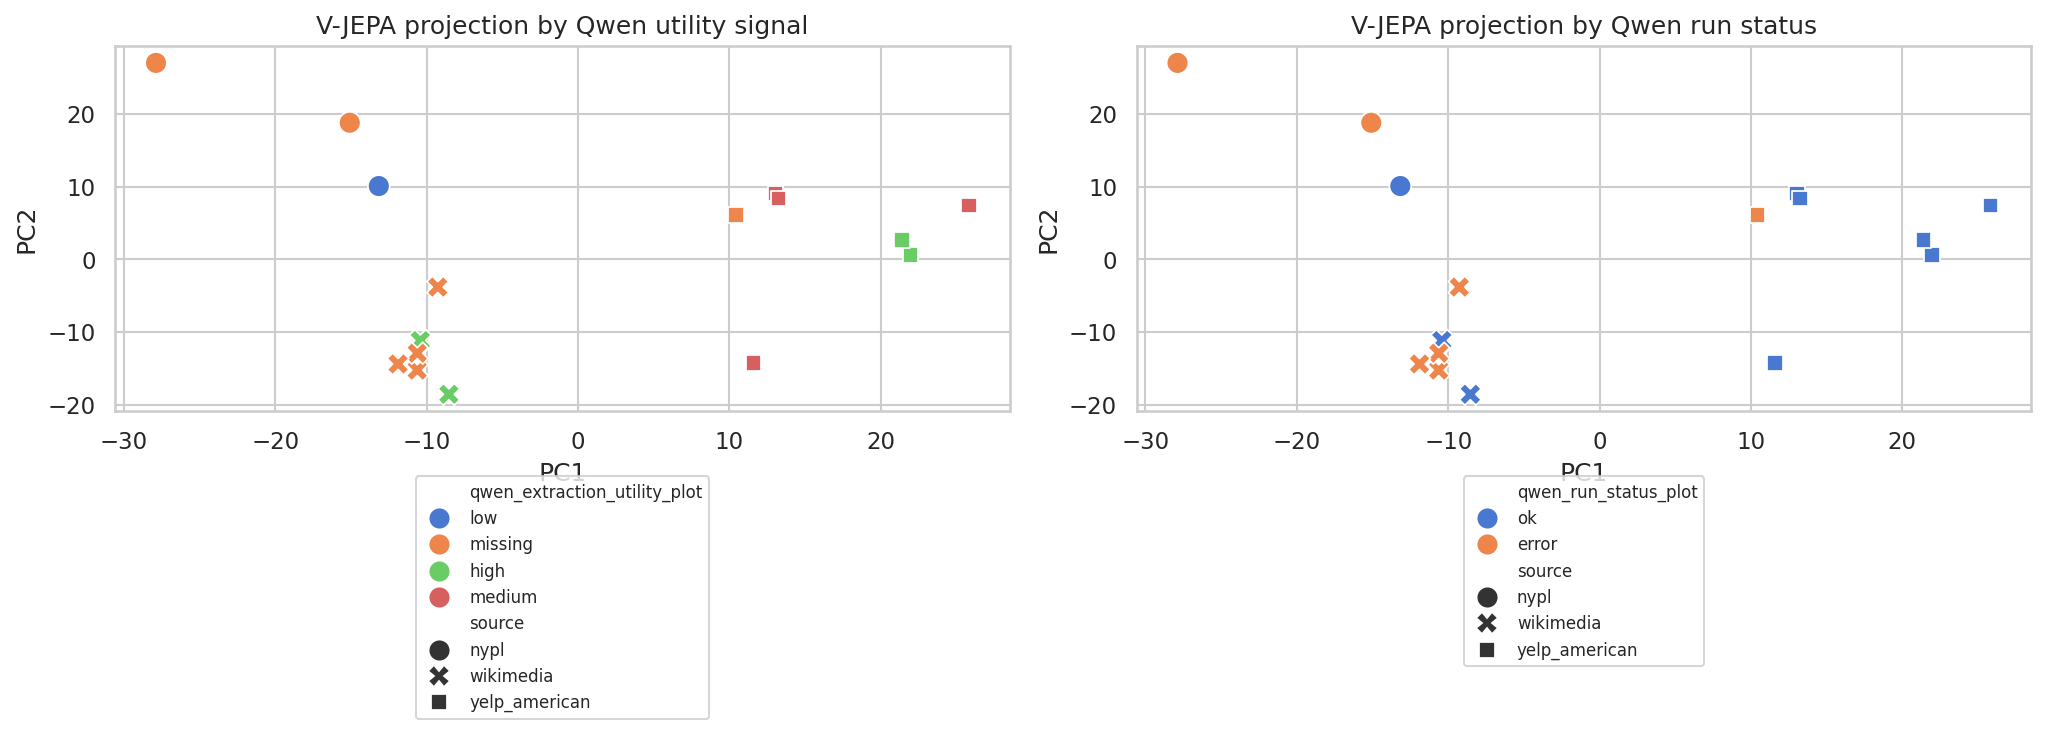

Saved figure: /home/endy/menuforge/outputs/figures/nb03c/fig26_vjepa_pca_by_qwen_signal.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.8, 6.4))

sns.scatterplot(
    data=plot_df,
    x="pc1",
    y="pc2",
    hue="qwen_extraction_utility_plot",
    style="source",
    s=110,
    ax=axes[0],
)
axes[0].set_title("V-JEPA projection by Qwen utility signal")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

if axes[0].get_legend() is not None:
    try:
        sns.move_legend(
            axes[0],
            "upper center",
            bbox_to_anchor=(0.5, -0.18),
            borderaxespad=0.0,
            frameon=True,
            fontsize=8,
            title_fontsize=9,
        )
    except Exception:
        handles, labels = axes[0].get_legend_handles_labels()
        axes[0].legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.18),
            borderaxespad=0.0,
            frameon=True,
            fontsize=8,
            title_fontsize=9,
        )

sns.scatterplot(
    data=plot_df,
    x="pc1",
    y="pc2",
    hue="qwen_run_status_plot",
    style="source",
    s=110,
    ax=axes[1],
)
axes[1].set_title("V-JEPA projection by Qwen run status")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

if axes[1].get_legend() is not None:
    try:
        sns.move_legend(
            axes[1],
            "upper center",
            bbox_to_anchor=(0.5, -0.18),
            borderaxespad=0.0,
            frameon=True,
            fontsize=8,
            title_fontsize=9,
        )
    except Exception:
        handles, labels = axes[1].get_legend_handles_labels()
        axes[1].legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.18),
            borderaxespad=0.0,
            frameon=True,
            fontsize=8,
            title_fontsize=9,
        )

fig.tight_layout(rect=(0, 0.14, 1, 1))
fig26 = FIG_DIR / "fig26_vjepa_pca_by_qwen_signal.png"
fig.savefig(fig26)
plt.show()

print(f"Saved figure: {fig26}")

## 10. Figure 27 — Outlier score by image

This is the most governance-oriented figure in the notebook. Lower mean cosine similarity
suggests a more visually unusual page relative to the rest of the subset.

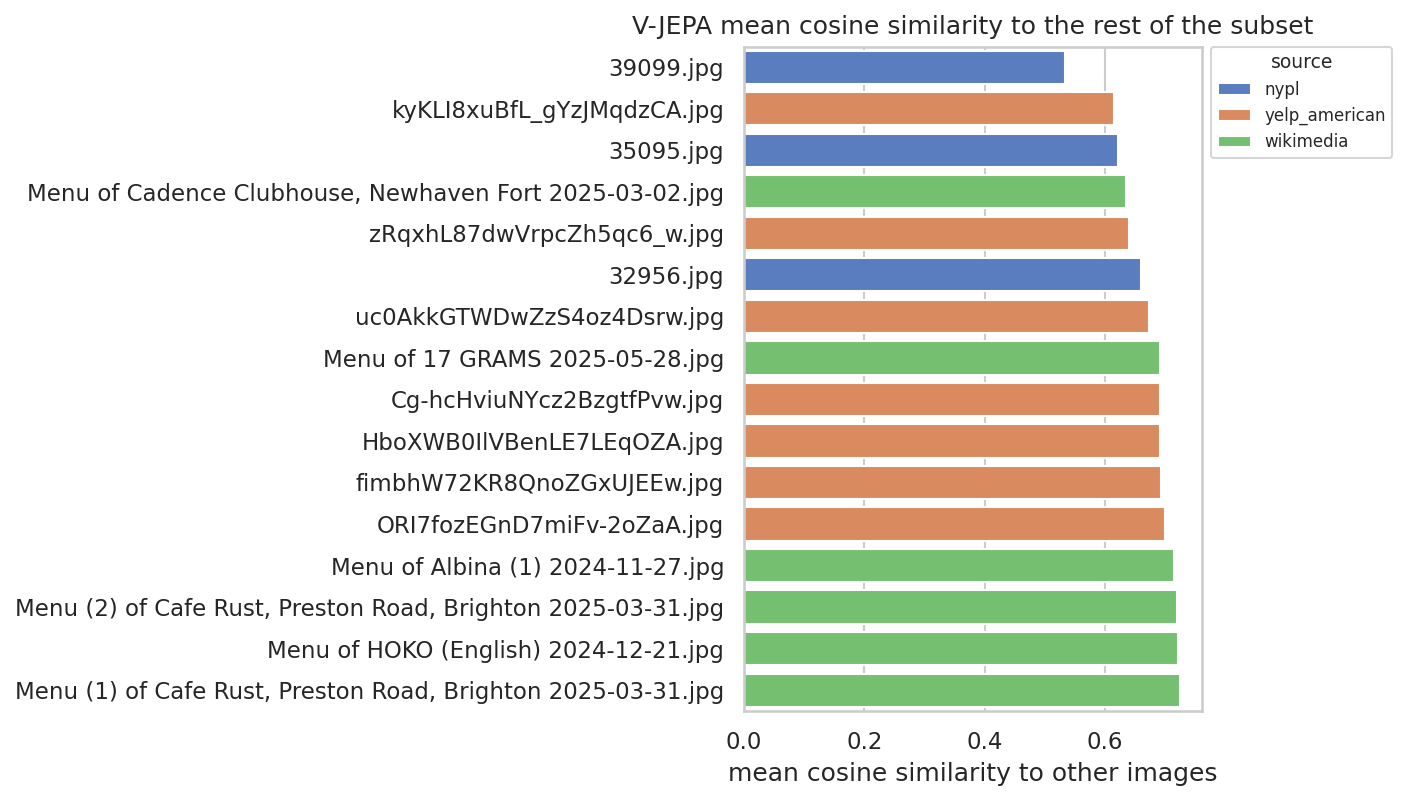

Saved figure: /home/endy/menuforge/outputs/figures/nb03c/fig27_vjepa_outlier_scores.png


In [11]:
outlier_df = plot_df.sort_values("mean_cosine_to_others", ascending=True).copy()

fig, ax = plt.subplots(figsize=(11.5, 5.5))
sns.barplot(
    data=outlier_df,
    x="mean_cosine_to_others",
    y="filename",
    hue="source",
    dodge=False,
    ax=ax,
)
ax.set_title("V-JEPA mean cosine similarity to the rest of the subset")
ax.set_xlabel("mean cosine similarity to other images")
ax.set_ylabel("")

if ax.get_legend() is not None:
    try:
        sns.move_legend(
            ax,
            "upper left",
            bbox_to_anchor=(1.02, 1.0),
            borderaxespad=0.0,
            frameon=True,
            fontsize=8,
            title_fontsize=9,
        )
    except Exception:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles,
            labels,
            loc="upper left",
            bbox_to_anchor=(1.02, 1.0),
            borderaxespad=0.0,
            frameon=True,
            fontsize=8,
            title_fontsize=9,
        )

fig.tight_layout(rect=(0, 0, 0.84, 1))

fig27 = FIG_DIR / "fig27_vjepa_outlier_scores.png"
fig.savefig(fig27)
plt.show()

print(f"Saved figure: {fig27}")

## 11. Optional unload

Release model memory before moving into later notebooks.

In [12]:
try:
    del model
    del processor
except NameError:
    pass

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("V-JEPA handles released.")

V-JEPA handles released.


## 12. Phase 3 handoff note

`NB03c` is complete when the saved embedding outputs show whether the frozen JEPA space is
useful for:

- grouping visually similar menu pages
- separating edge cases from stronger pages
- supporting later governance or retrieval arguments

The next notebook should then focus on **alignment rather than raw extraction**:

- `NB03d`: compare JEPA structure signals with Qwen understanding signals
- identify which pages are both semantically useful and visually central
- document where the two layers disagree, because those disagreements are analytically
  valuable for the horizon scan